<!-- config-banner -->
# 07 — Synthesis: do the adjoint sensitivities depend on vertical mixing, and what does that mean for the surrogate?

**The question (master plan, Part I).** Adjoint sensitivity maps are computed at
one set of parameter values. Do they remain valid when the vertical diffusivity
κ_v changes — is the response *flat* (published maps robust, mixing not needed as
a surrogate input) or *strong* (mixing must be an input, and the training set
must span the mixing range)? This notebook assembles the answer from notebooks
01–06 and spells out what it implies for the NN surrogate (master plan, Part II).

**Reads** (all under
`/scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/`):

- `cache/run_table.csv`, `cache/dJ_decomposition.csv`, `cache/stable_runs.npy`,
  `cache/member_metrics_time.nc`, `cache/timeseries_stats.nc`,
  `cache/jproxy_series.nc`, `cache/adxx_fields_3d.nc` — built by
  `build_cache.py` / `build_jproxy.py` (their docstrings are the inventory);
- the hand-off tables notebooks 01–06 left in `stats/`
  (`06_blowup_departure_table.csv`, `06_usable_window_ADJtheta_volume.csv`).

**Writes** figures to `figures/07_synthesis_and_interpretation/` and two
reusable summary tables to `stats/` — all on scratch, nothing into the
repository.

Every number quoted in the markdown below is printed by a code cell of this
notebook (recomputed from the cache) or explicitly cited to the notebook that
established it. Run table and suite reading order: `README.md` in this
directory. Analysis date: **2026-08-30**.

## 1. Evidence base — the member status table

One table gathers, per run, the quantities the verdict rests on, each recomputed
here from the cache rather than copied from another notebook's output:

- **fc** — the compiled cost `costfunction.0000` (forward-model quantity;
  `cache/run_table.csv`);
- **ΔJ measured / predicted** — `fc(member) − fc(REF)` against the linear
  adjoint prediction Σ ∂J/∂κ·Δκ + Σ ∂J/∂θ₀·Δθ₀ + Σ ∂J/∂S₀·ΔS₀ built from REF's
  own gradients (`cache/dJ_decomposition.csv`; the initial-**velocity** terms
  are structurally missing because `adxx_uvel/vvel` ≡ 0 — see §4);
- **corr / amp / sign at lead 5 yr** — final-snapshot (fully accumulated)
  `ADJtheta` pattern correlation, RMS amplitude ratio and sign-agreement
  fraction vs REF (`cache/member_metrics_time.nc` at time index 0 = iteration
  3162240 = lead 5.0 yr; volume-weighted, with the unweighted amplitude ratio
  alongside);
- **classification** — blown if outside `cache/stable_runs.npy` (criterion:
  final `ADJtheta` wet RMS and finiteness, build_cache.py); a stable member is
  downgraded to *degraded* when its final correlation is < 0.6 (that catches
  exactly M6, notebook 03/04);
- **departure lead / burst e-fold** — first lead (adjoint order) at which the
  member's `ADJtheta` RMS exceeds 10× REF's, and the steepest 30-day-window
  e-folding time of the RMS ratio during the divergence
  (`stats/06_blowup_departure_table.csv`, notebook 06);
- **usable lead (corr ≥ 0.5)** — longest lead with *sustained* volume-weighted
  correlation ≥ 0.5 vs REF (`stats/06_usable_window_ADJtheta_volume.csv`).

Below the table, four supporting evidence blocks are printed: the fc-curve
shape and REF's offset, the internal-variability noise floor recomputed from
the 200-yr cost-proxy series, the linearity verdict per member, and the
domain-summed dJ/dκ of the stable runs (the number a uniform-κ tuning argument
would use).

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ensemble_common as ec

ec.setup_style()
NB_STEM = "07_synthesis_and_interpretation"
ec.STATS_ROOT.mkdir(parents=True, exist_ok=True)

# Blown members carry RMS ~1e38 and amplitude ratios up to ~1e42: products and
# ratios overflow float64. That is expected and documented, so silence the
# warnings to keep the outputs readable.
np.seterr(over="ignore", invalid="ignore")
warnings.filterwarnings("ignore", message="overflow")

# ---- cache + hand-off products -------------------------------------------
run_table = pd.read_csv(ec.CACHE_DIR / "run_table.csv", index_col=0)
dj        = pd.read_csv(ec.CACHE_DIR / "dJ_decomposition.csv", index_col=0)
stable    = list(np.load(ec.CACHE_DIR / "stable_runs.npy", allow_pickle=True))
mm        = ec.open_cache("member_metrics_time.nc")
tss       = ec.open_cache("timeseries_stats.nc")
jp        = ec.open_cache("jproxy_series.nc")
dep       = pd.read_csv(ec.STATS_ROOT / "06_blowup_departure_table.csv", index_col=0)
usable    = pd.read_csv(ec.STATS_ROOT / "06_usable_window_ADJtheta_volume.csv", index_col=0)

# ---- final-snapshot ADJtheta metrics (lead 5 yr = time index 0) -----------
fin_v = mm.isel(time=0).sel(var="ADJtheta", weighting="volume")
fin_u = mm.isel(time=0).sel(var="ADJtheta", weighting="none")
assert float(mm.lead_years.isel(time=0)) == 5.0, "time index 0 must be lead 5 yr"

corr5 = {m: float(fin_v.corr.sel(member=m)) for m in ec.MEMBERS}
amp5v = {m: float(fin_v.amp_ratio.sel(member=m)) for m in ec.MEMBERS}
amp5u = {m: float(fin_u.amp_ratio.sel(member=m)) for m in ec.MEMBERS}
sign5 = {m: float(fin_v.sign_agree.sel(member=m)) for m in ec.MEMBERS}

def classify(run):
    if run == "REF":
        return "reference"
    if run not in stable:
        return "blown"
    return "degraded" if corr5[run] < 0.6 else "stable"

# ---- assemble the member status table -------------------------------------
tbl = pd.DataFrame(index=ec.RUN_ORDER)
tbl["kappa_factor"] = [ec.RUNS[r]["factor"] for r in ec.RUN_ORDER]
tbl["fc"] = run_table["fc"]
tbl["dJ_measured"] = dj["dJ_measured"].reindex(tbl.index)
tbl["dJ_predicted"] = dj["dJ_predicted_total"].reindex(tbl.index)
tbl["corr_lead5_vol"] = pd.Series(corr5).reindex(tbl.index)
tbl["amp_lead5_vol"] = pd.Series(amp5v).reindex(tbl.index)
tbl["amp_lead5_unw"] = pd.Series(amp5u).reindex(tbl.index)
tbl["sign_lead5_vol"] = pd.Series(sign5).reindex(tbl.index)
tbl.loc["REF", ["corr_lead5_vol", "amp_lead5_vol",
                "amp_lead5_unw", "sign_lead5_vol"]] = 1.0   # vs itself
tbl["class"] = [classify(r) for r in tbl.index]
tbl["dep_lead_yr"] = dep["dep_lead_yr"].reindex(tbl.index)
tbl["efold_burst_d"] = dep["efold_burst_days"].reindex(tbl.index)
tbl["usable_L_corr05_yr"] = usable["L_corr050_yr"].reindex(tbl.index)
tbl.loc["REF", "usable_L_corr05_yr"] = np.inf

out_csv = ec.STATS_ROOT / "07_member_status_table.csv"
tbl.to_csv(out_csv)
print(f"saved {out_csv}\n")

show = tbl.copy()
for c in ["fc", "dJ_measured", "dJ_predicted", "corr_lead5_vol",
          "sign_lead5_vol"]:
    show[c] = show[c].map(lambda v: f"{v:+.3f}" if np.isfinite(v) else "—")
for c in ["amp_lead5_vol", "amp_lead5_unw"]:   # blown members reach ~1e42
    show[c] = tbl[c].map(lambda v: "—" if not np.isfinite(v)
                         else (f"{v:.3f}" if abs(v) < 100 else f"{v:.3g}"))
for c in ["dep_lead_yr", "efold_burst_d", "usable_L_corr05_yr"]:
    show[c] = tbl[c].map(lambda v: "—" if not np.isfinite(v)
                         else ("full" if v == np.inf else f"{v:.2f}"))
show["usable_L_corr05_yr"] = tbl["usable_L_corr05_yr"].map(
    lambda v: "full 5.0" if np.isinf(v) else ("—" if not np.isfinite(v) else f"{v:.2f}"))
print("MEMBER STATUS TABLE  (final snapshot = lead 5 yr; ADJtheta metrics vs REF)")
print(show.to_string())

# ---- evidence block 1: the fc curve and REF's offset ----------------------
fc = run_table["fc"]
fc_ref = float(fc["REF"])
mem_by_kappa = ec.MEMBERS  # already ordered by kappa
monotonic = bool(np.all(np.diff([fc[m] for m in mem_by_kappa]) > 0))
interp_1x = 0.5 * (fc["M2"] + fc["M3"])   # linear in log2(kappa) between 0.5x and 2x
offset = fc_ref - interp_1x
print("\n--- fc curve -------------------------------------------------------")
print(f"members monotonic in kappa: {monotonic}   "
      f"(fc {fc['M1']:.4f} at 0.25x -> {fc['M7']:.4f} at 32x, "
      f"x{fc['M7']/fc['M1']:.2f})")
print(f"fc(REF) = {fc_ref:.4f}; member interpolation at 1x = {interp_1x:.4f}; "
      f"REF offset = {offset:+.4f}")

# ---- evidence block 2: noise floor from the 200-yr proxy series -----------
my = jp.model_year.values
sel = my >= my.max() - 100.0
inst = jp.jproxy.values[sel]
sig_inst = float(np.std(inst, ddof=1))
ann = pd.Series(inst).groupby(np.floor(my[sel]).astype(int)).mean()
sig_ann = float(ann.std(ddof=1))
print("\n--- internal-variability noise floor (last 100 yr of the spin-up) --")
print(f"sigma_inst (30.5-d instantaneous samples) = {sig_inst:.4f}")
print(f"sigma_ann  (annual means)                 = {sig_ann:.4f}")
print(f"REF offset above member curve             = {offset:.4f}  "
      f"= {offset/sig_inst:.1f} sigma_inst / {offset/sig_ann:.1f} sigma_ann")
dj_abs = dj["dJ_measured"].abs()
m_small = dj_abs.idxmin()
print(f"smallest member departure |dJ|: {m_small} {dj_abs[m_small]:.4f}  "
      f"= {dj_abs[m_small]/sig_inst:.1f} sigma_inst / "
      f"{dj_abs[m_small]/sig_ann:.1f} sigma_ann  -> every kappa signal "
      f"clears the floor")

# ---- evidence block 3: linearity of the adjoint prediction ----------------
print("\n--- linear-gradient prediction vs measured dJ ----------------------")
for m in mem_by_kappa:
    meas, pred = dj.loc[m, "dJ_measured"], dj.loc[m, "dJ_predicted_total"]
    ok = np.sign(meas) == np.sign(pred)
    print(f"  {m} ({ec.RUNS[m]['factor']:5g}x): measured {meas:+.4f}  "
          f"predicted {pred:+.4f}  sign {'OK  ' if ok else 'WRONG'} "
          f"pred/meas {pred/meas:+.2f}")
wrong = [m for m in mem_by_kappa
         if np.sign(dj.loc[m, "dJ_measured"]) != np.sign(dj.loc[m, "dJ_predicted_total"])]
within30 = [m for m in mem_by_kappa
            if abs(dj.loc[m, "dJ_predicted_total"] / dj.loc[m, "dJ_measured"] - 1) < 0.3]
print(f"  -> wrong sign for {len(wrong)}/7 members ({', '.join(wrong)}); "
      f"predicted within 30%: {within30 if within30 else 'none'}")

# ---- evidence block 4: ADJdiffkr transferability (the surrogate target) ---
fin_k = mm.isel(time=0).sel(var="ADJdiffkr", weighting="volume")
print("\n--- ADJdiffkr (the surrogate target field) at lead 5 yr vs REF -----")
for m in ["M2", "M3", "M6"]:
    print(f"  {m} ({ec.RUNS[m]['factor']:3g}x): corr "
          f"{float(fin_k.corr.sel(member=m)):.2f}   amp ratio "
          f"x{float(fin_k.amp_ratio.sel(member=m)):.2f}   sign "
          f"{float(fin_k.sign_agree.sel(member=m)):.2f}")
print("  -> far less transferable than ADJtheta (structure AND amplitude)")

# ---- evidence block 5: domain-summed dJ/dkappa of the stable runs ---------
adxx = ec.open_cache("adxx_fields_3d.nc")
print("\n--- domain-summed adxx_diffkr = dJ/d(uniform kappa) [per m2/s] -----")
sums = {}
for r in ["M2", "REF", "M3", "M6"]:
    sums[r] = float(np.nansum(adxx["field"].sel(run=r, var="adxx_diffkr").values))
    print(f"  {r} ({ec.RUNS[r]['factor']:g}x): {sums[r]:+.1f}")
adxx.close()
print("  -> the gradient itself is strongly kappa-dependent and flips sign by 16x")

saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/stats/07_member_status_table.csv

MEMBER STATUS TABLE  (final snapshot = lead 5 yr; ADJtheta metrics vs REF)
     kappa_factor      fc dJ_measured dJ_predicted corr_lead5_vol amp_lead5_vol amp_lead5_unw sign_lead5_vol      class dep_lead_yr efold_burst_d usable_L_corr05_yr
M1           0.25  +0.214      -0.117       +0.037         -0.011      4.78e+08      4.98e+08         +0.549      blown        2.55          3.22               2.53
M2           0.50  +0.260      -0.071       +0.036         +0.818         1.323         1.365         +0.801     stable           —             —           full 5.0
REF          1.00  +0.331           —            —         +1.000         1.000         1.000         +1.000  reference           —             —           full 5.0
M3           2.00  +0.265      -0.066       -0.047         +0.845         0.777         0.770         +0.858     stable           —             —           f

### Reading the table, and where each fact was established

The table splits the ensemble into three populations: **stable** M2 (0.5×) and
M3 (2×), which finish the full 5-yr reverse sweep with reference-like structure;
**degraded** M6 (16×), stable by RMS but only half-correlated with REF at lead
5 yr; and **blown** M1, M4, M5, M7 (0.25×, 4×, 8×, 32×), whose reverse sweeps
diverge at member-specific leads while their *forward* fc values stay perfectly
healthy. Note the non-monotonicity in κ down the `class` column — the smallest
perturbation (0.25×) blows up while 16× does not.

Traceability map (each notebook's own summary carries the full statement):

| fact | established in |
| --- | --- |
| completeness (366 dumps × 11 vars × 9 runs), bit-identical provenance 30995 = 28486, noise floor, ΔJ decomposition | 01 |
| reference adjoint anatomy: ADJdiffkr accumulation ×657, southern-hemisphere migration, only 8 of 14 adxx controls non-zero | 02 |
| member maps, blow-up non-monotonicity, blown-member anatomy | 03 |
| magnitude-vs-structure metrics per variable/depth/lead | 04 |
| ensemble spread geography, variable ranking by normalised spread | 05 |
| departure leads, burst e-fold times, usable windows, animations | 06 |

## 2. Executive summary

**The answer to Part I's question is "strong response" — and it is strong in two
different ways at once: the sensitivities depend physically on κ_v, and the
adjoint itself has a stability boundary that the ensemble crosses
non-monotonically.** Every claim below is traceable to a notebook (in
parentheses) and to the numbers printed above.

1. **The forward response is smooth, monotonic and strong**: fc rises 0.214 →
   0.510 (×2.4) across the 128-fold κ range, strictly monotonic across the
   seven members (01).
2. **Every member's ΔJ clears the internal-variability noise floor** — σ ≈
   0.007 (annual) to 0.012 (instantaneous) in fc units from the 200-yr proxy
   series; the smallest departure (M5, 0.029) is 2.4 σ_inst ≈ 4.1 σ_ann (01).
3. **REF's +0.069 offset above the member curve is not noise (5.7 σ_inst)**: it
   is a κ-symmetric transient weakening of the transport during the members'
   10-yr adjustment, already present in their year-2180 initial states — the
   fc(κ) curve is monotonic κ response + symmetric restart-adjustment dip +
   comparatively negligible internal noise (01).
4. **Four of seven adjoints blow up — non-monotonically in κ**: departure leads
   M7 (32×) 0.36 yr, M4 (4×) 0.72 yr, M5 (8×) 1.28 yr, M1 (0.25×) 2.56 yr,
   while M2 (0.5×), M3 (2×) and M6 (16×) never cross 10× REF. The instability
   is a property of each member's own background trajectory, not of the κ value
   (06, 03).
5. **The blow-up is an instability of the linearised (adjoint) dynamics**:
   episodic, with steepest 30-d burst e-fold times of 1.0–3.2 days; all four
   seed in the Southern Ocean channel sector (38–51°S), three abyssally; only
   M4 ever loses finiteness (first inf/NaN ~2.2 yr *after* its RMS departure).
   Forward legs and fc are healthy in all nine runs, and the AD internal
   consistency adxx_diffkr ≡ final ADJdiffkr (corr 1.000000) holds even in
   blown runs (06, 03, 01).
6. **Where the adjoint is stable, structure survives and magnitude shifts**:
   final-snapshot ADJtheta corr 0.82 (M2) / 0.85 (M3), sign agreement 0.80 /
   0.86, amplitude ratios 1.32 / 0.78 (volume-weighted; 1.36 / 0.77
   unweighted) — lower κ amplifies, higher κ damps, by tens of percent (04).
7. **M6 (16×) is genuinely intermediate**: RMS-stable but corr 0.49 and
   amplitude 0.56 at lead 5 yr, structurally usable only to lead ~2.6 yr —
   "stable by RMS" is not "reference-like" (03, 04).
8. **ADJdiffkr — the surrogate's target field — is the least transferable
   variable**: corr 0.66 / 0.21 / 0.05 and amplitude ×8.4 / ×0.32 / ×0.33 for
   M2 / M3 / M6, and the domain-summed dJ/dκ runs −251 / −436 / −78 / +673
   (M2 / REF / M3 / M6) — a sign flip by 16× (04, 05, 03).
9. **The linear gradient does not predict member-to-member ΔJ**: wrong sign for
   M1, M2, M6, M7; no member within 30%. The direct κ term is an order of
   magnitude too small; κ enters J mainly through the 10-yr adjusted mean state
   whose θ and S contributions are large and nearly cancel — the trust radius
   of the raw gradient for uniform-κ perturbations is **below a factor 2** (01).
10. **All members — blown ones included — agree with REF at short lead**
    (corr 0.92–1.00 at lead 5 d; sustained corr ≥ 0.9 for 25–70 d): the
    terminal-30-day cost forcing dominates there, because J is a
    terminal-month mean, not a 5-yr mean (04, 06, 01/02).
11. **The compiled J is decomposition-dependent** (per-tile countV
    normalisation; the section spans 3 tiles at nPx=3), and is verified to be
    ≈ the per-tile transport index of the initial pickup within 3–19% — fc
    values are only comparable between runs with the same tiling: a
    PORTING-level trap (01).
12. **Ensemble agreement is minority-of-domain**: only 8–29% of wet cells pass
    |mean| > 2·std (stable subset); surface-flux sensitivities (ADJqnet,
    ADJempmr) carry the largest normalised spread, the 3-D state sensitivities
    the smallest; ADJtheta robustness *increases* toward the cost depth (05).
13. **A wiring gap caveats the state-term decomposition**: only 8 of 14 adxx
    control gradients are non-zero — adxx_uvel/vvel *and* all four wind
    controls (tauu/tauv/uwind/vwind) are identically zero, the stress gradient
    arriving in adxx_fu/fv instead. (The planning spec said 12 non-zero; 02
    measured 8.) The ΔJ prediction therefore misses the initial-velocity
    contribution (02, 01).
14. **Long-lead reference sensitivity lives in the other hemisphere and below
    the cost integral**: peak |adxx_theta| at 19.6°S / 391 m, ADJtheta RMS
    maximal at ~2430 m, ADJdiffkr accumulating ×657 over the sweep with an
    intense shallow equatorial band — the 26°N section's upstream supply
    routes, not the section vicinity (02).
15. **Provenance is clean**: run 30995 reproduces production run 28486
    bit-identically with `useGrdchk=.FALSE.`, saving 8.2 h (36%) per adjoint
    run — the whole ensemble inherited that setting (01).

## 3. The summary figure

Four panels, all recomputed from the cache in the cell below — this is the
figure to put in front of the advisor:

- **(a) fc vs κ with the noise floor.** Member fc (viridis-graded by κ, dashed
  interpolation) and REF (black star) against the ±2σ internal-variability
  bands (light: instantaneous σ; dark: annual-mean σ) centred on fc(REF). The
  members' monotonic curve, the significance of every departure, and REF's
  restart-adjustment offset are all visible at once.
- **(b) Structure vs κ.** Final-snapshot (lead 5 yr) volume-weighted ADJtheta
  pattern correlation vs REF. Filled = stable, half-filled sense conveyed by
  annotation for degraded M6, open = blown (those values are noise, plotted
  only to show they are noise). REF ≡ 1 by definition.
- **(c) When each adjoint departs.** Wet-RMS of ADJtheta vs lead time for all
  nine runs (log y), with each blown member's departure lead (first lead at
  RMS ≥ 10× REF) marked by an open circle. The adjoint computes left→right in
  this coordinate (increasing lead = backwards in model time).
- **(d) The linearity failure.** Measured ΔJ = fc(member) − fc(REF) next to
  the linear adjoint prediction (κ + initial-state terms; velocity terms
  missing — §4) per member.

saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/07_synthesis_and_interpretation/synthesis_4panel.png


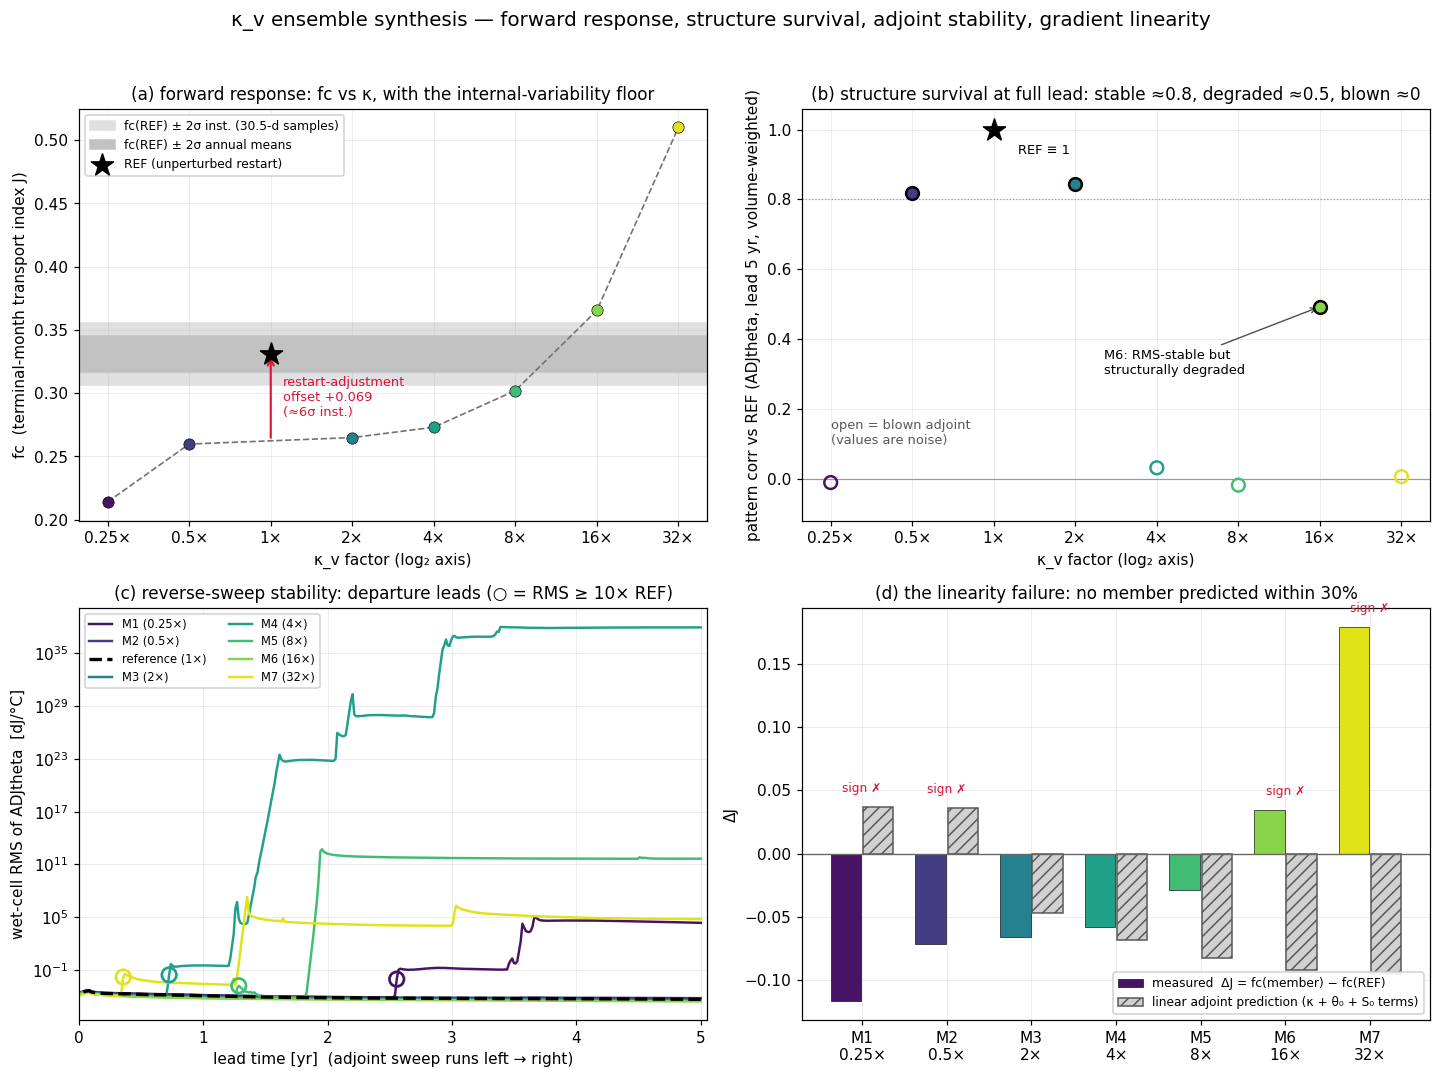

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(13.2, 9.8))
axa, axb, axc, axd = axes.ravel()

lg2 = {r: np.log2(ec.RUNS[r]["factor"]) for r in ec.RUN_ORDER}
xt = [np.log2(f) for f in [0.25, 0.5, 1, 2, 4, 8, 16, 32]]
xtl = ["0.25×", "0.5×", "1×", "2×", "4×", "8×", "16×", "32×"]

# ---------------- (a) fc vs kappa with noise-floor bands -------------------
axa.axhspan(fc_ref - 2 * sig_inst, fc_ref + 2 * sig_inst, color="0.88",
            zorder=0, label="fc(REF) ± 2σ inst. (30.5-d samples)")
axa.axhspan(fc_ref - 2 * sig_ann, fc_ref + 2 * sig_ann, color="0.76",
            zorder=1, label="fc(REF) ± 2σ annual means")
mx = [lg2[m] for m in ec.MEMBERS]
mf = [fc[m] for m in ec.MEMBERS]
axa.plot(mx, mf, ls="--", color="0.45", lw=1.1, zorder=2)
for m in ec.MEMBERS:
    axa.scatter(lg2[m], fc[m], s=55, color=ec.member_color(m), zorder=4,
                edgecolor="k", lw=0.4)
axa.scatter(0, fc_ref, marker="*", s=230, color="black", zorder=5,
            label="REF (unperturbed restart)")
axa.annotate("", xy=(0, fc_ref), xytext=(0, interp_1x),
             arrowprops=dict(arrowstyle="->", color="crimson", lw=1.4))
axa.annotate(f"restart-adjustment\noffset {offset:+.3f}\n"
             f"(≈{offset/sig_inst:.0f}σ inst.)", xy=(0.15, 0.5 * (fc_ref + interp_1x)),
             fontsize=8.5, color="crimson", va="center")
axa.set_xticks(xt); axa.set_xticklabels(xtl)
axa.set_xlabel("κ_v factor (log₂ axis)")
axa.set_ylabel("fc  (terminal-month transport index J)")
axa.set_title("(a) forward response: fc vs κ, with the internal-variability floor")
axa.legend(loc="upper left", fontsize=8)

# ---------------- (b) final structure agreement vs kappa -------------------
axb.axhline(0, color="0.6", lw=0.8)
axb.axhline(0.8, color="0.6", lw=0.8, ls=":")
for m in ec.MEMBERS:
    blown = tbl.loc[m, "class"] == "blown"
    kw = dict(s=70, zorder=4, lw=1.6)
    if blown:
        axb.scatter(lg2[m], corr5[m], facecolors="none",
                    edgecolors=ec.member_color(m), **kw)
    else:
        axb.scatter(lg2[m], corr5[m], color=ec.member_color(m),
                    edgecolor="k", **kw)
axb.scatter(0, 1.0, marker="*", s=230, color="black", zorder=5)
axb.annotate("REF ≡ 1", xy=(0, 1.0), xytext=(0.3, 0.93), fontsize=8.5)
axb.annotate("M6: RMS-stable but\nstructurally degraded",
             xy=(4, corr5["M6"]), xytext=(1.35, 0.30), fontsize=8.5,
             arrowprops=dict(arrowstyle="->", lw=0.9, color="0.3"))
axb.annotate("open = blown adjoint\n(values are noise)", xy=(-2, 0.10),
             fontsize=8.5, color="0.35")
axb.set_xticks(xt); axb.set_xticklabels(xtl)
axb.set_ylim(-0.12, 1.06)
axb.set_xlabel("κ_v factor (log₂ axis)")
axb.set_ylabel("pattern corr vs REF (ADJtheta, lead 5 yr, volume-weighted)")
axb.set_title("(b) structure survival at full lead: stable ≈0.8, degraded ≈0.5, blown ≈0")

# ---------------- (c) RMS vs lead with departure leads ---------------------
lead = tss.lead_years.values
for r in ec.RUN_ORDER:
    y = tss.rms.sel(run=r, var="ADJtheta").values
    axc.plot(lead, y, **ec.line_kwargs(r))
for m in ec.MEMBERS:
    L = tbl.loc[m, "dep_lead_yr"]
    if np.isfinite(L):
        i = int(np.argmin(np.abs(lead - L)))
        axc.scatter(lead[i], tss.rms.sel(run=m, var="ADJtheta").values[i],
                    facecolors="none", edgecolors=ec.member_color(m), s=90,
                    lw=1.8, zorder=6)
axc.set_yscale("log")
axc.set_xlim(0, 5.05)
axc.set_xlabel("lead time [yr]  (adjoint sweep runs left → right)")
axc.set_ylabel("wet-cell RMS of ADJtheta  [dJ/°C]")
axc.set_title("(c) reverse-sweep stability: departure leads (○ = RMS ≥ 10× REF)")
axc.legend(ncol=2, fontsize=7.5, loc="upper left")

# ---------------- (d) measured vs predicted dJ -----------------------------
xs = np.arange(len(ec.MEMBERS))
meas = [dj.loc[m, "dJ_measured"] for m in ec.MEMBERS]
pred = [dj.loc[m, "dJ_predicted_total"] for m in ec.MEMBERS]
axd.axhline(0, color="0.4", lw=0.9)
axd.bar(xs - 0.19, meas, 0.36,
        color=[ec.member_color(m) for m in ec.MEMBERS],
        edgecolor="k", lw=0.4, label="measured  ΔJ = fc(member) − fc(REF)")
axd.bar(xs + 0.19, pred, 0.36, color="0.82", hatch="///",
        edgecolor="0.35", label="linear adjoint prediction (κ + θ₀ + S₀ terms)")
for x, mv, pv in zip(xs, meas, pred):
    if np.sign(mv) != np.sign(pv):
        axd.annotate("sign ✗", xy=(x, max(mv, pv) + 0.012), ha="center",
                     fontsize=8, color="crimson")
axd.set_xticks(xs)
axd.set_xticklabels([f"{m}\n{ec.RUNS[m]['factor']:g}×" for m in ec.MEMBERS])
axd.set_ylabel("ΔJ")
axd.set_title("(d) the linearity failure: no member predicted within 30%")
axd.legend(fontsize=8, loc="lower right")

fig.suptitle("κ_v ensemble synthesis — forward response, structure survival, "
             "adjoint stability, gradient linearity", y=0.995, fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.975))
ec.save_fig(fig, NB_STEM, "synthesis_4panel")
plt.show()

**Reading the figure.** Panel (a) contains the forward half of the answer: a
strong, smooth, monotonic fc(κ) curve whose member departures all clear the
grey noise bands, plus REF's crimson-arrowed offset — the restarted members
share a κ-symmetric adjustment dip that internal variability cannot produce.
Panel (b) contains the adjoint half: at full lead the structure of the
sensitivity survives a factor-2 κ change essentially intact (≈0.82–0.85),
survives 16× only in degraded form (≈0.49), and does not survive at all in the
four blown members — whose open markers sit at ≈0 *regardless of their κ*.
Panel (c) shows why: the blown members leave REF's RMS curve at four different
leads with no κ ordering (32× first, then 4×, 8×, and — most strikingly — the
*smallest* perturbation 0.25× last), each within episodes of 1–3-day e-folding
growth (notebook 06). Panel (d) is the linearisation verdict: the reference
gradient, applied to the actual member perturbations (κ change + adjusted
initial state), gets the *sign* of ΔJ wrong for four of seven members,
including the factor-0.5 neighbour — the fc curve's κ dependence is real but
not linearisable from a single adjoint at this perturbation size.

## 4. Implications for the NN surrogate (master plan, Part II)

Part II's design assumed the answer to Part I would decide whether κ_v is a
surrogate *input*. It is now decided — and the ensemble constrains the training
data more specifically than the plan anticipated. The cell below quantifies the
two operative numbers: the **training-data budget** (how many of the ensemble's
5-day sensitivity dumps are physically usable as training targets, given each
member's stability horizon) and the **accuracy target** (the internal-variability
noise floor expressed as a relative error on J).

For the budget, two per-member bounds are counted from the 366-dump lead axis:

- dumps at leads **shorter than the RMS departure lead** (notebook 06's
  criterion — the validity bound for blown members, since structure loss and
  RMS departure coincide to within one dump);
- dumps inside the stricter **sustained corr ≥ 0.5 window** (the
  similarity-to-REF bound; conservative for stable members whose physical
  κ response legitimately lowers the correlation).

In [3]:
leads = tss.lead_years.values          # descending 5.0 -> 0.014, 366 dumps
n_dumps = leads.size

rows = []
for m in ec.MEMBERS:
    Ld = tbl.loc[m, "dep_lead_yr"]                 # NaN for non-blown
    L5 = tbl.loc[m, "usable_L_corr05_yr"]          # inf for M2/M3
    n_dep = int((leads < Ld).sum()) if np.isfinite(Ld) else n_dumps
    n_c05 = int((leads <= L5).sum()) if np.isfinite(L5) else n_dumps
    rows.append(dict(member=m, kappa=f"{ec.RUNS[m]['factor']:g}x",
                     cls=tbl.loc[m, "class"],
                     n_below_departure=n_dep, frac_dep=n_dep / n_dumps,
                     n_corr05=n_c05, frac_corr05=n_c05 / n_dumps,
                     full_lead5_target=(n_dep == n_dumps)))
budget = pd.DataFrame(rows).set_index("member")
out_csv = ec.STATS_ROOT / "07_training_data_budget.csv"
budget.to_csv(out_csv)
print(f"saved {out_csv}\n")
print("TRAINING-DATA BUDGET  (366 five-day dumps per run; REF adds 366 more)")
print(budget.to_string(
    formatters=dict(frac_dep="{:.0%}".format, frac_corr05="{:.0%}".format)))

tot_dep = int(budget["n_below_departure"].sum()) + n_dumps      # + REF
tot_all = n_dumps * (len(ec.MEMBERS) + 1)
print(f"\ntotal usable dumps (departure-lead bound, incl. REF): "
      f"{tot_dep}/{tot_all} = {tot_dep/tot_all:.0%}")
full5 = [m for m in ec.MEMBERS if budget.loc[m, "full_lead5_target"]]
full5_factors = ", ".join(f"{ec.RUNS[m]['factor']:g}x" for m in full5)
print(f"members providing the FULL-WINDOW (lead-5-yr) dJ/dκ target: "
      f"{', '.join(full5)} + REF  (κ factors {full5_factors} + 1x; "
      f"M6 16x survives by RMS but is structurally degraded, corr "
      f"{corr5['M6']:.2f})")

print("\nACCURACY TARGET from the noise floor (01):")
print(f"  sigma_ann..sigma_inst = {sig_ann:.4f}..{sig_inst:.4f} in J units "
      f"= {sig_ann/fc_ref:.1%}..{sig_inst/fc_ref:.1%} of fc(REF)")
print(f"  smallest significant member signal: |dJ(M5)| = "
      f"{abs(dj.loc['M5','dJ_measured']):.4f} "
      f"({abs(dj.loc['M5','dJ_measured'])/fc_ref:.1%} of fc)")
print("  -> a surrogate gradient whose implied dJ errs by less than ~0.007 "
      "(the annual-mean floor) is indistinguishable from internal "
      "variability — a natural stopping criterion for training accuracy "
      "on integrated quantities.")

saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/stats/07_training_data_budget.csv

TRAINING-DATA BUDGET  (366 five-day dumps per run; REF adds 366 more)
        kappa       cls  n_below_departure frac_dep  n_corr05 frac_corr05  full_lead5_target
member                                                                                      
M1      0.25x     blown                186      51%       185         51%              False
M2       0.5x    stable                366     100%       366        100%               True
M3         2x    stable                366     100%       366        100%               True
M4         4x     blown                 52      14%        51         14%              False
M5         8x     blown                 93      25%        92         25%              False
M6        16x  degraded                366     100%       193         53%               True
M7        32x     blown                 25       7%        23          6%    

### What this means for the surrogate design

1. **κ_v must be an input** (Part II's FiLM conditioning on scalar parameters):
   the response is strong in structure (ADJdiffkr corr drops to 0.21 already at
   2×) and in amplitude (domain-summed dJ/dκ −251 → −436 → −78 → +673 across
   0.5×–16×, a sign flip). A published single-κ sensitivity map is *not* robust
   to mixing uncertainty beyond roughly a factor 2.
2. **A linear-in-κ surrogate is inadequate across factor-2 changes** — the
   reference gradient itself mispredicts ΔJ's sign at 0.5× (notebook 01).
   κ enters through the slowly adjusted mean state, so the surrogate's κ input
   effectively parameterises a *family of background states*, exactly the
   $(\bar{\mathbf{x}}, \boldsymbol{\theta})$ pairing of the Part II design.
3. **Training data from a κ ensemble is bounded by adjoint stability, not by
   compute**: as run, only 0.5×–2× (plus REF, plus the structurally degraded
   16×) deliver full-window lead-5-yr targets; the blown members deliver only
   lead-limited pairs (budget above: ~62% of the ensemble's dumps survive the
   departure-lead bound, but the surviving *long-lead* targets cluster at
   small |Δκ|). Part II's "biggest
   open question" — how far back the labels stay meaningful — now has an
   ensemble answer: **the horizon is member-dependent, 0.36–2.6 yr for the four
   blown members and ≥ 5 yr for 0.5×–2×.** Options, in order of preference:
   adjViscBoost-stabilised reruns (§5), per-member lead caps when building
   training pairs, or shorter adjoint windows for large |Δκ|.
4. **The noise floor is the natural accuracy target**: σ ≈ 0.007–0.012 in J
   units (2.1–3.7% of fc). Driving a surrogate's *integrated* gradient error
   below that is chasing internal variability of the label-generating model.
5. **The zero-control wiring gap must be resolved before initial-state targets
   are trusted**: adxx_uvel/vvel ≡ 0 (and the four wind controls too — the
   stress gradient lives in adxx_fu/fv). Either wire the velocity controls or
   drop velocity initial-condition gradients from the target inventory; today's
   ΔJ decomposition (and any training pair built from it) silently omits that
   term (02, 01).
6. **ADJdiffkr's 15-decade central dynamic range and top-heavy vertical
   structure** (02) support Part II's asinh transform + separate log-amplitude
   head; the near-50/50 sign split makes the pattern-cosine term important.
7. **Label reproducibility caveat**: the compiled J is decomposition-dependent
   (per-tile countV). All labels must be generated at nPx=3 × nPy=9, or the
   cost code fixed first — regenerating labels on a different tiling changes J
   itself (01; PORTING.md-level flag).

## 5. Recommended follow-ups, priority-ordered

1. **κ = 1 control member ("M0").** Rerun the 10-yr forward leg *unperturbed*
   from the year-2170 pickup of spin-up 30983, then its 5-yr adjoint — the
   missing datum separating "restart + adjustment" from "κ physics", and a
   second sample of the noise floor. Concretely: add
   `input/variants/kappa_v_ensemble/data_M0` (copy of `data_M3` with
   `kappaRho`/`diffKrT` left at 1.2e-5) and submit the same chained pair as the
   members (`IMPACTS_TEST_CASE=kappa_v_ensemble/M0
   ../../../tools/submit.sh submit_frd.sh`, then the adjoint with
   `--dependency=afterok`, pickup symlink pointed at M0's own year-2180
   pickup). Prediction from notebook 01: its fc should land near 0.26 (the
   member curve), ~0.07 below REF — confirming the offset is the restart
   adjustment, not noise.
2. **adjViscBoost reruns of the blown members** (M4 first: worst case and
   cheapest to interpret). The repo carries the stabiliser precisely for this:
   `./build_tapAdj_adjViscBoost.sh` +
   `../../../tools/submit.sh submit_tapAdj_adjViscBoost.sh` (viscFacInAd = 10
   via `data.autodiff_adjViscBoost`), with the run's pickup symlink pointed at
   the member's year-2180 pickup. **Run M3-boost as well**: M3-plain is stable,
   so M3-boost vs M3-plain measures the boost's own bias on the sensitivities —
   without that pair, boosted targets from M4/M5/M7 are uninterpretable.
3. **Finer κ sampling inside the stable range**: members at 0.7×, 1.4×
   (and 1.2×, 0.85× if budget allows) where full 5-yr windows are known to
   survive — this is where a first κ-conditioned surrogate can actually be
   trained and tested, and it brackets the trust-radius question at |Δκ| <
   factor 2 that notebook 01 exposed.
4. **Repair the gradient check at a sensitive point** (master plan
   prerequisite): move `data.grdchk` to the high-sensitivity cell
   (`iGloPos=2, jGloPos=127, kGloPos=26`, per the repo notes) and raise
   `grdchk_eps` to ~1e-3, run **one** short adjoint with `useGrdchk=.TRUE.` —
   the ensemble's FD comparison (01) is necessarily contaminated by the
   state-adjustment term; a clean point check is the complementary validation.
5. **Wire or drop the velocity controls** (`xx_uvel/vvel` in `data.ctrl`):
   decide before any surrogate training on initial-state gradients; the fix
   also completes the ΔJ decomposition of notebook 01.
6. **When any of the above runs**: re-run `build_cache.py` (safe, overwrites)
   and re-execute notebooks 01/03–06; this synthesis reads only the cache and
   the stats hand-offs, so it updates by re-execution alone.

## 6. Open questions and honest limitations

- **The stable subset has four points** (0.5×, 1×, 2×, 16×), one of them
  degraded — the ensemble statistics of notebook 05 are a spread, not a
  distribution, and any κ-interpolation of sensitivities rests on M2–REF–M3
  alone.
- **One perturbation pattern**: uniform scaling of a spatially uniform κ_v.
  Nothing here constrains sensitivity to *spatially structured* mixing changes
  (the master plan's eventual 3-D κ field input), and the blow-up's dependence
  on the background trajectory suggests structured perturbations could behave
  differently again.
- **One cost functional** (terminal-month, per-tile-normalised 26°N transport
  index, upper 982 m). The migration of long-lead sensitivity into the southern
  hemisphere (02) is presumably functional-specific; Part II's multi-section
  ambition needs its own ensembles.
- **M6's intermediate state is unexplained**: RMS-stable for 5 yr yet
  structurally half-degraded (corr 0.49) with its correlation eroding from
  ~2.6 yr without ever bursting. Whether that is a slow instability, a large
  physical κ response, or both mixed, deserves its own look (a 16×
  adjViscBoost pair would separate the two).
- **Why these four members?** The departure leads are non-monotonic in κ and
  the seeds sit in the Southern Ocean channel at depth (06), pointing at
  member-specific abyssal stratification/shear states — but the mechanism
  (which linearised process goes unstable, and why 0.25× but not 0.5×) is
  undiagnosed. A targeted look at the M1/M5 background states around their
  seed locations is the entry point.
- **The noise floor is proxy-based and single-realisation**: instantaneous
  30.5-d snapshots (aliased, fixed seasonal phases) from one 200-yr spin-up;
  σ_inst is an upper bound on the 30-d-mean σ, σ_ann a lower one, and the
  per-decade spread of σ is itself ~×2 (01). The M0 control member (§5.1) is
  the cheapest way to add an independent sample.
- **Metric error bars**: all correlations/amplitudes are computed against a
  single reference realisation; there is no internal-variability error bar on
  the *fields* (01 quantifies it only for J). Bootstrapping over sub-windows of
  the adjoint dumps would be a cheap first estimate.